In [31]:
"""
NS-SDN (Non-Stationary Spectral Decomposition Network) — PyTorch-native reference implementation.

Implements the *network only*:
- Latent state transition: GRUCell (state-space / RNN-style)
- Emission: trend + K nonstationary oscillators with state-driven amplitude, frequency, and phase offset
- Phase accumulation: theta_n = theta_{n-1} + omega_n * dt_n  (discrete-time integration)

Notes:
- This implementation is intentionally "PyTorch-native": nn.Module, nn.GRUCell, vectorized math, no exotic deps.
- Supports scalar output (m=1) or multivariate output (m>1) by choosing amplitude/frequency/offset parameterization.

Shapes:
- x:  (B, T, in_dim)   (typically in_dim=1 for univariate autoregressive)
- dt: (B, T) or (T,)   (dt[:, 0] should be 0 or you can pass dt with dt[0]=0)
- yhat: (B, T, out_dim)
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Literal, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F

In [32]:
@dataclass
class NSSDNOutputs:
    yhat: torch.Tensor                      # (B, T, out_dim)
    h: torch.Tensor                         # (B, T, d_state)
    B: torch.Tensor                         # (B, T, out_dim)
    A: torch.Tensor                         # (B, T, K, out_dim) or (B, T, K)
    omega: torch.Tensor                     # (B, T, K, out_dim) or (B, T, K)
    varphi: torch.Tensor                    # (B, T, K, out_dim) or (B, T, K)
    theta: torch.Tensor                     # (B, T, K, out_dim) or (B, T, K)
    components: torch.Tensor                # (B, T, K, out_dim)  contribution of each component

In [33]:
class NSSDN(nn.Module):
    """
    Non-Stationary Spectral Decomposition Network (NS-SDN).

    Parameters
    ----------
    in_dim:
        Input dimension at each time step (e.g., 1 if x_n = y_n).
    out_dim:
        Output dimension (1 for scalar, >1 for multivariate).
    d_state:
        Latent state dimension.
    K:
        Number of spectral components.
    transition:
        "gru" (recommended) or "euler" (time-aware Euler step).
    per_output_params:
        If True, A/omega/varphi/theta are per-output-dimension (shape ... K, out_dim).
        If False, they are shared across outputs (shape ... K) and then mixed to out_dim via an output mixer.
    omega_base:
        Base angular frequencies. Either:
          - float: scalar broadcast to all k
          - Tensor shape (K,) or (K, out_dim) if per_output_params
    """

    def __init__(self, in_dim: int = 1, out_dim: int = 1, d_state: int = 64, K: int = 8, transition: Literal["gru", "euler"] = "gru",
                 per_output_params: bool = True, omega_base: float | torch.Tensor = 0.0, constrain_omega_positive: bool = False) -> None:
        super().__init__()

        self.in_dim = int(in_dim)
        self.out_dim = int(out_dim)
        self.d_state = int(d_state)
        self.K = int(K)
        self.transition = transition
        self.per_output_params = bool(per_output_params)
        self.constrain_omega_positive = bool(constrain_omega_positive)

        # ---------- Transition (state-space) ----------
        if transition == "gru":
            self.cell = nn.GRUCell(input_size=self.in_dim, hidden_size=self.d_state)
            self.euler_net = None
        elif transition == "euler":
            # h_n = h_{n-1} + dt_n * g(h_{n-1}, x_n)
            self.cell = None
            self.euler_net = nn.Sequential(
                nn.Linear(self.d_state + self.in_dim, self.d_state),
                nn.Tanh(),
                nn.Linear(self.d_state, self.d_state),
            )
        else:
            raise ValueError(f"transition must be 'gru' or 'euler', got {transition}")

        # ---------- Emission heads ----------
        # Trend: B_n = w_B^T h_n + b_B  (vector if out_dim > 1)
        self.trend = nn.Linear(self.d_state, self.out_dim)

        # Spectral parameter heads
        # A_n = softplus(W_A h_n + b_A)  (positive)
        # omega_n = omega_base + W_omega h_n + b_omega
        # varphi_n = W_varphi h_n + b_varphi

        if self.per_output_params:
            # Each component has parameters per output dimension:
            # (B,T,d_state) -> (B,T, K*out_dim) -> reshape (B,T,K,out_dim)
            self.amp_head = nn.Linear(self.d_state, self.K * self.out_dim)
            self.omg_head = nn.Linear(self.d_state, self.K * self.out_dim)
            self.phi_head = nn.Linear(self.d_state, self.K * self.out_dim)

            # theta0 learned per (k, out_dim)
            self.theta0 = nn.Parameter(torch.zeros(self.K, self.out_dim))
            self.output_mixer = None
        else:
            # Shared K parameters, then mix K components to out_dim
            self.amp_head = nn.Linear(self.d_state, self.K)
            self.omg_head = nn.Linear(self.d_state, self.K)
            self.phi_head = nn.Linear(self.d_state, self.K)

            # theta0 learned per k
            self.theta0 = nn.Parameter(torch.zeros(self.K))
            # mixer maps K component signals -> out_dim
            self.output_mixer = nn.Linear(self.K, self.out_dim, bias=False)

        # omega_base buffer
        omega_base_t = self._normalize_omega_base(omega_base)
        self.register_buffer("omega_base", omega_base_t)

    def _normalize_omega_base(self, omega_base: float | torch.Tensor) -> torch.Tensor:
        if isinstance(omega_base, (float, int)):
            if self.per_output_params:
                return torch.full((self.K, self.out_dim), float(omega_base))
            return torch.full((self.K,), float(omega_base))
        if not torch.is_tensor(omega_base):
            raise TypeError("omega_base must be float|int or torch.Tensor")

        if self.per_output_params:
            if omega_base.ndim == 1 and omega_base.shape[0] == self.K:
                return omega_base[:, None].repeat(1, self.out_dim).clone()
            if omega_base.ndim == 2 and omega_base.shape == (self.K, self.out_dim):
                return omega_base.clone()
            raise ValueError(f"omega_base must be shape (K,) or (K,out_dim), got {tuple(omega_base.shape)}")
        else:
            if omega_base.ndim == 1 and omega_base.shape[0] == self.K:
                return omega_base.clone()
            raise ValueError(f"omega_base must be shape (K,), got {tuple(omega_base.shape)}")

    @staticmethod
    def _ensure_dt(dt: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """
        Accept dt as (T,) or (B,T). Return (B,T).
        """
        if dt.ndim == 1:
            return dt[None, :].expand(x.shape[0], -1)
        if dt.ndim == 2:
            return dt
        raise ValueError(f"dt must be (T,) or (B,T), got {tuple(dt.shape)}")

    def _transition_step(self, h_prev: torch.Tensor, x_n: torch.Tensor, dt_n: torch.Tensor) -> torch.Tensor:
        """
        h_prev: (B, d_state)
        x_n:    (B, in_dim)
        dt_n:   (B,) or (B,1)
        """
        if self.transition == "gru":
            return self.cell(x_n, h_prev)

        # Euler step
        if dt_n.ndim == 1:
            dt_n = dt_n[:, None]  # (B,1)
        inp = torch.cat([h_prev, x_n], dim=-1)  # (B, d_state+in_dim)
        dh = self.euler_net(inp)                # (B, d_state)
        return h_prev + dt_n * dh

    def forward(self, x: torch.Tensor, dt: torch.Tensor, h0: Optional[torch.Tensor] = None,
        theta0: Optional[torch.Tensor] = None, return_diagnostics: bool = True) -> NSSDNOutputs | torch.Tensor:
        """
        Parameters
        ----------
        x:
            (B, T, in_dim)
        dt:
            (T,) or (B, T); dt[:,0] should be 0 (or very small) if you want theta_0 to apply at n=0 cleanly.
        h0:
            Optional initial state (B, d_state). If None, zeros.
        theta0:
            Optional initial phase overriding learned theta0.
            - if per_output_params: (B, K, out_dim) or (K, out_dim)
            - else: (B, K) or (K,)
        return_diagnostics:
            If False, returns yhat only.
        """
        if x.ndim != 3:
            raise ValueError(f"x must be (B,T,in_dim), got {tuple(x.shape)}")
        Bsz, T, Din = x.shape
        if Din != self.in_dim:
            raise ValueError(f"x last dim must be in_dim={self.in_dim}, got {Din}")

        dt = self._ensure_dt(dt, x)  # (B,T)

        device = x.device
        dtype = x.dtype

        # init h
        if h0 is None:
            h_prev = torch.zeros(Bsz, self.d_state, device=device, dtype=dtype)
        else:
            if h0.shape != (Bsz, self.d_state):
                raise ValueError(f"h0 must be (B,d_state)=({Bsz},{self.d_state}), got {tuple(h0.shape)}")
            h_prev = h0

        # init theta
        if self.per_output_params:
            base_theta0 = self.theta0  # (K,out_dim)
            if theta0 is None:
                theta_prev = base_theta0[None, :, :].expand(Bsz, -1, -1).to(device=device, dtype=dtype)  # (B,K,out_dim)
            else:
                theta_prev = self._coerce_theta0(theta0, Bsz, device, dtype)  # (B,K,out_dim)
        else:
            base_theta0 = self.theta0  # (K,)
            if theta0 is None:
                theta_prev = base_theta0[None, :].expand(Bsz, -1).to(device=device, dtype=dtype)  # (B,K)
            else:
                theta_prev = self._coerce_theta0(theta0, Bsz, device, dtype)  # (B,K)

        # storage
        h_path = []
        B_path = []
        A_path = []
        omg_path = []
        phi_path = []
        tht_path = []
        comp_path = []
        yhat_path = []

        # main loop over time
        for n in range(T):
            x_n = x[:, n, :]          # (B,in_dim)
            dt_n = dt[:, n]           # (B,)

            # update latent state
            h_n = self._transition_step(h_prev, x_n, dt_n)  # (B,d_state)

            # trend
            B_n = self.trend(h_n)  # (B,out_dim)

            # spectral params from state
            if self.per_output_params:
                A_n = F.softplus(self.amp_head(h_n)).view(Bsz, self.K, self.out_dim)  # (B,K,out_dim)
                omega_n = self.omg_head(h_n).view(Bsz, self.K, self.out_dim)          # (B,K,out_dim)
                varphi_n = self.phi_head(h_n).view(Bsz, self.K, self.out_dim)         # (B,K,out_dim)

                omega_n = omega_n + self.omega_base[None, :, :].to(device=device, dtype=dtype)

                if self.constrain_omega_positive:
                    # preserve base as a floor if you want: omega = omega_base + softplus(delta)
                    # here we just softplus the total omega; adjust if you want a different convention
                    omega_n = F.softplus(omega_n)

                # theta update: theta_n = theta_{n-1} + omega_n * dt_n
                theta_n = theta_prev + omega_n * dt_n[:, None, None]  # (B,K,out_dim)

                # component synthesis (expanded identity not needed; direct sin is stable)
                comp_n = A_n * torch.sin(theta_n + varphi_n)          # (B,K,out_dim)
                y_n = B_n + comp_n.sum(dim=1)                         # (B,out_dim)
            else:
                A_n = F.softplus(self.amp_head(h_n))                  # (B,K)
                omega_n = self.omg_head(h_n) + self.omega_base[None, :].to(device=device, dtype=dtype)  # (B,K)
                varphi_n = self.phi_head(h_n)                         # (B,K)

                if self.constrain_omega_positive:
                    omega_n = F.softplus(omega_n)

                theta_n = theta_prev + omega_n * dt_n[:, None]        # (B,K)

                comp_scalar = A_n * torch.sin(theta_n + varphi_n)     # (B,K)
                comp_n = comp_scalar[:, :, None]                      # (B,K,1) for storage uniformity

                # mix K components -> out_dim (or sum then project; here we mix directly)
                y_n = B_n + self.output_mixer(comp_scalar)            # (B,out_dim)

            # store
            h_path.append(h_n)
            B_path.append(B_n)

            A_path.append(A_n)
            omg_path.append(omega_n)
            phi_path.append(varphi_n)
            tht_path.append(theta_n)
            comp_path.append(comp_n)
            yhat_path.append(y_n)

            # carry forward
            h_prev = h_n
            theta_prev = theta_n

        # stack time
        h_path_t = torch.stack(h_path, dim=1)           # (B,T,d_state)
        B_path_t = torch.stack(B_path, dim=1)           # (B,T,out_dim)
        yhat_t = torch.stack(yhat_path, dim=1)          # (B,T,out_dim)

        # diagnostics: unify shapes
        if self.per_output_params:
            A_t = torch.stack(A_path, dim=1)            # (B,T,K,out_dim)
            omega_t = torch.stack(omg_path, dim=1)      # (B,T,K,out_dim)
            varphi_t = torch.stack(phi_path, dim=1)     # (B,T,K,out_dim)
            theta_t = torch.stack(tht_path, dim=1)      # (B,T,K,out_dim)
            components_t = torch.stack(comp_path, dim=1)# (B,T,K,out_dim)
        else:
            A_t = torch.stack(A_path, dim=1)            # (B,T,K)
            omega_t = torch.stack(omg_path, dim=1)      # (B,T,K)
            varphi_t = torch.stack(phi_path, dim=1)     # (B,T,K)
            theta_t = torch.stack(tht_path, dim=1)      # (B,T,K)
            components_t = torch.stack(comp_path, dim=1)# (B,T,K,1)

        if not return_diagnostics:
            return yhat_t

        return NSSDNOutputs(
            yhat=yhat_t,
            h=h_path_t,
            B=B_path_t,
            A=A_t,
            omega=omega_t,
            varphi=varphi_t,
            theta=theta_t,
            components=components_t,
        )

    def _coerce_theta0(self, theta0: torch.Tensor, Bsz: int, device, dtype) -> torch.Tensor:
        """
        Coerce user-provided theta0 to batch shape.
        """
        if self.per_output_params:
            if theta0.ndim == 2 and theta0.shape == (self.K, self.out_dim):
                return theta0[None, :, :].expand(Bsz, -1, -1).to(device=device, dtype=dtype)
            if theta0.ndim == 3 and theta0.shape == (Bsz, self.K, self.out_dim):
                return theta0.to(device=device, dtype=dtype)
            raise ValueError(
                f"theta0 must be (K,out_dim)=({self.K},{self.out_dim}) or (B,K,out_dim)=({Bsz},{self.K},{self.out_dim}), "
                f"got {tuple(theta0.shape)}"
            )
        else:
            if theta0.ndim == 1 and theta0.shape == (self.K,):
                return theta0[None, :].expand(Bsz, -1).to(device=device, dtype=dtype)
            if theta0.ndim == 2 and theta0.shape == (Bsz, self.K):
                return theta0.to(device=device, dtype=dtype)
            raise ValueError(
                f"theta0 must be (K,)=({self.K},) or (B,K)=({Bsz},{self.K}), got {tuple(theta0.shape)}"
            )



In [34]:
import fedfred as fd

fred = fd.FredAPI(api_key="7ab121fb17773e187bb6508e83e411da")

gdp = fred.get_series_observations(series_id="CBBTCUSD", observation_start="2000-01-01", observation_end="2025-12-31")

print(gdp.tail())

           realtime_start realtime_end     value
date                                            
2025-12-27     2026-02-23   2026-02-23  87844.66
2025-12-28     2026-02-23   2026-02-23  88029.48
2025-12-29     2026-02-23   2026-02-23  87055.23
2025-12-30     2026-02-23   2026-02-23  88185.26
2025-12-31     2026-02-23   2026-02-23  87696.00


In [35]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

# --- 1) Clean dataframe -> sorted time series ---
df = gdp.copy()

# FRED: sometimes "date" is the index, not a column
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])
else:
    df = df.copy()
    df["date"] = pd.to_datetime(df.index)

# remove index to avoid "date" ambiguity
df = df.reset_index(drop=True)

# value column handling
if "value" not in df.columns:
    data_cols = [c for c in df.columns if c != "date"]
    if len(data_cols) == 1:
        df = df.rename(columns={data_cols[0]: "value"})
    else:
        raise ValueError(f"Expected a 'value' column (or exactly 1 data column). Got columns={list(df.columns)}")

df = df.sort_values("date").reset_index(drop=True)

# coerce numeric, drop missing
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df.dropna(subset=["value"]).reset_index(drop=True)

# raw series
y_raw = df["value"].to_numpy(dtype=np.float32)  # (N,)

# --- 2) Build sliding windows: x[t..t+T-1] -> target y[t+1..t+T] ---
T = 24  # window length

# dt in years between observations (per step)
t_days = df["date"].values.astype("datetime64[D]").astype("int64")
dt_all = np.zeros_like(y_raw, dtype=np.float32)
dt_all[1:] = (t_days[1:] - t_days[:-1]).astype(np.float32) / 365.25

# transform for stability (important for BTC/USD-like series)
y_log = np.log1p(y_raw)

# compute split on windows (no leakage)
Nw = len(y_log) - (T + 1)
if Nw <= 0:
    raise ValueError(f"Not enough points N={len(y_log)} for window length T={T}")
split = int(Nw * 0.8)

# training windows touch y indices up to (split + T) inclusive
train_end = split + T + 1  # exclusive
mu = float(y_log[:train_end].mean())
sd = float(y_log[:train_end].std() + 1e-6)

# z-score using train stats only
y = ((y_log - mu) / sd).astype(np.float32)

def make_windows(y: np.ndarray, dt: np.ndarray, T: int):
    xs, ys, dts = [], [], []
    for i in range(len(y) - (T + 1)):
        x_seq = y[i : i + T]
        y_seq = y[i + 1 : i + T + 1]
        dt_seq = dt[i : i + T].copy()
        dt_seq[0] = 0.0
        xs.append(x_seq[:, None])   # (T,1)
        ys.append(y_seq[:, None])   # (T,1)
        dts.append(dt_seq)          # (T,)
    return np.stack(xs), np.stack(ys), np.stack(dts)

X_np, Y_np, DT_np = make_windows(y, dt_all, T)
# shapes: X=(Nw,T,1), Y=(Nw,T,1), DT=(Nw,T)

# --- 3) Train/test split (time-based to avoid leakage) ---
Nw = X_np.shape[0]
split = int(Nw * 0.8)
Xtr, Ytr, Dtr = X_np[:split], Y_np[:split], DT_np[:split]
Xte, Yte, Dte = X_np[split:], Y_np[split:], DT_np[split:]

# torch tensors
device = "cuda" if torch.cuda.is_available() else "cpu"
Xtr_t = torch.from_numpy(Xtr).to(device)
Ytr_t = torch.from_numpy(Ytr).to(device)
Dtr_t = torch.from_numpy(Dtr).to(device)

Xte_t = torch.from_numpy(Xte).to(device)
Yte_t = torch.from_numpy(Yte).to(device)
Dte_t = torch.from_numpy(Dte).to(device)

train_loader = DataLoader(TensorDataset(Xtr_t, Dtr_t, Ytr_t), batch_size=32, shuffle=True)

# --- 4) Instantiate + train NSSDN ---
model = NSSDN(
    in_dim=1,
    out_dim=1,
    d_state=64,
    K=8,
    transition="gru",
    per_output_params=True,
    constrain_omega_positive=True,
).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

model.train()
for epoch in range(200):
    total = 0.0
    for xb, dtb, yb in train_loader:
        opt.zero_grad(set_to_none=True)
        yhat = model(xb, dtb, return_diagnostics=False)  # (B,T,1) in z-space
        loss = loss_fn(yhat, yb)
        loss.backward()
        opt.step()
        total += loss.item() * xb.size(0)

    if (epoch + 1) % 25 == 0:
        print(f"epoch {epoch+1:3d} | train_mse(z)={total/len(train_loader.dataset):.6f}")

# --- 5) Prediction on test windows ---
model.eval()
with torch.no_grad():
    yhat_te = model(Xte_t, Dte_t, return_diagnostics=False)  # (Ntest,T,1) in z-space
    test_mse = loss_fn(yhat_te, Yte_t).item()

print("test_mse(z):", test_mse)

# helper: invert z->log->raw for quick sanity check on last window
y_true_last = np.expm1((Yte_t[-1, :5, 0].detach().cpu().numpy() * sd) + mu)
y_pred_last = np.expm1((yhat_te[-1, :5, 0].detach().cpu().numpy() * sd) + mu)
print("last test window (true next-step, raw)  :", y_true_last)
print("last test window (pred next-step, raw)  :", y_pred_last)

epoch  25 | train_mse(z)=0.000601
epoch  50 | train_mse(z)=0.000579
epoch  75 | train_mse(z)=0.000563
epoch 100 | train_mse(z)=0.000571
epoch 125 | train_mse(z)=0.000546
epoch 150 | train_mse(z)=0.000558
epoch 175 | train_mse(z)=0.000542
epoch 200 | train_mse(z)=0.000536
test_mse(z): 0.00023530663747806102
last test window (true next-step, raw)  : [90435.41  90338.34  92243.555 91194.96  91784.61 ]
last test window (pred next-step, raw)  : [88819.09  90348.42  89987.26  92092.805 90749.28 ]


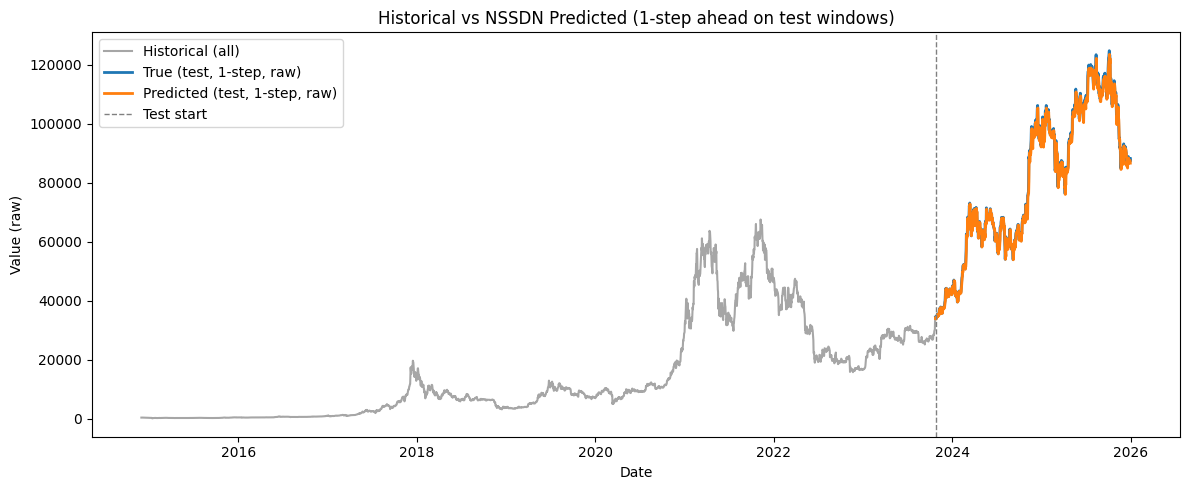

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# 1-step ahead series across test windows (use the last step in each window) -- in z space
y_true_test_z = Yte_t[:, -1, 0].detach().cpu().numpy()
y_pred_test_z = yhat_te[:, -1, 0].detach().cpu().numpy()

# invert: z -> log -> raw
y_true_test = np.expm1(y_true_test_z * sd + mu)
y_pred_test = np.expm1(y_pred_test_z * sd + mu)

# Map each test-window prediction to its corresponding timestamp:
# window i predicts y[i+T] at the last step, so date index is i+T
test_dates = df["date"].iloc[split + T : split + T + len(y_true_test)].to_numpy()

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["value"], label="Historical (all)", color="black", alpha=0.35)
plt.plot(test_dates, y_true_test, label="True (test, 1-step, raw)", linewidth=2)
plt.plot(test_dates, y_pred_test, label="Predicted (test, 1-step, raw)", linewidth=2)

plt.axvline(test_dates[0], color="gray", linestyle="--", linewidth=1, label="Test start")
plt.title("Historical vs NSSDN Predicted (1-step ahead on test windows)")
plt.xlabel("Date")
plt.ylabel("Value (raw)")
plt.legend()
plt.tight_layout()
plt.show()